# 🔧 Feature Engineering — Budgetly Capstone
**Tujuan:** Menghasilkan fitur-fitur baru yang lebih informatif dari data transaksi keuangan mahasiswa untuk mendukung analisis lanjutan dan model prediktif.

**Input:** `Data_Final_Combine_with_Persona.csv`  
**Output:** `df_features.csv`

---
### Daftar Fitur yang Akan Dibuat
| No | Fitur | Deskripsi |
|---|---|---|
| 1 | `spending_ratio` | Rasio pengeluaran terhadap pemasukan per bulan |
| 2 | `savings_rate` | Persentase uang yang berhasil ditabung |
| 3 | `daily_avg_expense` | Rata-rata pengeluaran harian per persona per bulan |
| 4 | `dominant_category` | Kategori pengeluaran terbesar per bulan |
| 5 | `makan_ratio` | Proporsi pengeluaran Makan & Minum |
| 6 | `hiburan_ratio` | Proporsi pengeluaran Hiburan |
| 7 | `weekend_ratio` | Proporsi pengeluaran di akhir pekan vs hari kerja |
| 8 | `expense_volatility` | Volatilitas pengeluaran harian (konsistensi) |
| 9 | `high_spend_flag` | Flag hari dengan pengeluaran abnormal tinggi |
| 10 | `month_sin / month_cos` | Cyclical encoding bulan |
| 11 | `day_sin / day_cos` | Cyclical encoding hari dalam seminggu |
| 12 | `mom_expense_change` | Perubahan pengeluaran bulan ke bulan (%) |

## 0. Import Library

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0f1117'
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print('✅ Libraries loaded')

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Data-Science/Notebook')

✅ Libraries loaded
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load Data

In [26]:
df = pd.read_csv('../Dataset/Processed/Data_Final_Combine_with_Persona.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
print(f'\nPersona distribution:')
print(df['Persona'].value_counts())
df.head(3)

Shape: (4981, 10)
Kolom: ['Date', 'Description', 'Amount', 'Transaction_Type', 'Category', 'Account_Name', 'Month', 'Month_Name', 'Day_of_Week', 'Persona']

Persona distribution:
Persona
Persona 1 - Si Hemat (Data Asli)    1200
Persona 2 - Agak Boros              1145
Persona 3 - Hemat Banget             991
Persona 4 - Anak Nongkrong           915
Persona 1 - Si Hemat                 730
Name: count, dtype: int64


,Date,Description,Amount,Transaction_Type,Category,Account_Name,Month,Month_Name,Day_of_Week,Persona
0,2025-07-01,Parkir,15907.28,EXPENSE,Tagihan,Gopay,7,July,Tuesday,Persona 1 - Si Hemat (Data Asli)
1,2025-07-01,Iuran Bulanan,12793.08,EXPENSE,Tagihan,BCA,7,July,Tuesday,Persona 1 - Si Hemat (Data Asli)
2,2025-07-01,Lain-lain,695.24,EXPENSE,Lain-lain,Gopay,7,July,Tuesday,Persona 1 - Si Hemat (Data Asli)


## 2. Persiapan Data Dasar

In [27]:
# Pisahkan expense dan income
df_exp = df[df['Transaction_Type'] == 'EXPENSE'].copy()
df_inc = df[df['Transaction_Type'] == 'INCOME'].copy()

# Tambah kolom bantu
df['YearMonth'] = df['Date'].dt.to_period('M')
df_exp['YearMonth'] = df_exp['Date'].dt.to_period('M')
df_inc['YearMonth'] = df_inc['Date'].dt.to_period('M')

# Identifikasi akhir pekan
df_exp['is_weekend'] = df_exp['Date'].dt.dayofweek >= 5  # Sabtu=5, Minggu=6

print(f'Expense rows: {len(df_exp):,}')
print(f'Income rows:  {len(df_inc):,}')

Expense rows: 4,747
Income rows:  234


## 3. Feature Engineering — Level Bulanan per Persona
> Fitur-fitur ini dihitung per kombinasi `Persona × YearMonth`

### 3.1 Total Pengeluaran & Pemasukan Bulanan

In [28]:
# Total expense per persona per bulan
monthly_exp = (
    df_exp.groupby(['Persona', 'YearMonth'])['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'total_expense'})
)

# Total income per persona per bulan
monthly_inc = (
    df_inc.groupby(['Persona', 'YearMonth'])['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'total_income'})
)

# Gabung
monthly = pd.merge(monthly_exp, monthly_inc, on=['Persona', 'YearMonth'], how='outer').fillna(0)
print(monthly.head(6))

                Persona YearMonth  total_expense  total_income
0  Persona 1 - Si Hemat   2024-01      3736607.0     4498619.0
1  Persona 1 - Si Hemat   2024-02      1359593.0     4828696.0
2  Persona 1 - Si Hemat   2024-03      2679837.0     2616507.0
3  Persona 1 - Si Hemat   2024-04      2687896.0     3870859.0
4  Persona 1 - Si Hemat   2024-05      2681309.0     2343601.0
5  Persona 1 - Si Hemat   2024-06      3381217.0     2284627.0


### 3.2 Spending Ratio & Savings Rate

In [29]:
# spending_ratio = total_expense / total_income
# Jika income = 0, set ratio = None (tidak terdefinisi)
monthly['spending_ratio'] = np.where(
    monthly['total_income'] > 0,
    monthly['total_expense'] / monthly['total_income'],
    np.nan
)

# savings_rate = (income - expense) / income × 100
monthly['savings_rate'] = np.where(
    monthly['total_income'] > 0,
    (monthly['total_income'] - monthly['total_expense']) / monthly['total_income'] * 100,
    np.nan
)

# net_balance per bulan
monthly['net_balance'] = monthly['total_income'] - monthly['total_expense']

print('=== Spending Ratio per Persona (rata-rata) ===')
print(monthly.groupby('Persona')[['spending_ratio','savings_rate']].mean().round(3).to_string())

=== Spending Ratio per Persona (rata-rata) ===
                                  spending_ratio  savings_rate
Persona                                                       
Persona 1 - Si Hemat                       0.803        19.687
Persona 1 - Si Hemat (Data Asli)           0.639        36.112
Persona 2 - Agak Boros                     0.719        28.073
Persona 3 - Hemat Banget                   6.799      -579.918
Persona 4 - Anak Nongkrong                 4.898      -389.835


### 3.3 Rata-rata Pengeluaran Harian

In [30]:
# Jumlah hari aktif bertransaksi per bulan per persona
active_days = (
    df_exp.groupby(['Persona', 'YearMonth'])['Date']
    .nunique()
    .reset_index()
    .rename(columns={'Date': 'active_days'})
)

monthly = pd.merge(monthly, active_days, on=['Persona', 'YearMonth'], how='left')

# daily_avg_expense = total_expense / active_days
monthly['daily_avg_expense'] = monthly['total_expense'] / monthly['active_days']

print('=== Rata-rata Pengeluaran Harian per Persona ===')
print(monthly.groupby('Persona')['daily_avg_expense'].mean()
      .apply(lambda x: f'Rp {x:,.0f}'.replace(',','.'))
      .to_string())

=== Rata-rata Pengeluaran Harian per Persona ===
Persona
Persona 1 - Si Hemat                 Rp 99.093
Persona 1 - Si Hemat (Data Asli)     Rp 51.389
Persona 2 - Agak Boros              Rp 133.412
Persona 3 - Hemat Banget             Rp 39.485
Persona 4 - Anak Nongkrong          Rp 241.151


### 3.4 Dominant Category

In [31]:
# Kategori pengeluaran terbesar per persona per bulan
dominant_cat = (
    df_exp.groupby(['Persona', 'YearMonth', 'Category'])['Amount']
    .sum()
    .reset_index()
    .sort_values('Amount', ascending=False)
    .groupby(['Persona', 'YearMonth'])
    .first()
    .reset_index()[['Persona', 'YearMonth', 'Category']]
    .rename(columns={'Category': 'dominant_category'})
)

monthly = pd.merge(monthly, dominant_cat, on=['Persona', 'YearMonth'], how='left')

print('=== Dominant Category per Persona ===')
print(monthly.groupby('Persona')['dominant_category'].value_counts().to_string())

=== Dominant Category per Persona ===
Persona                           dominant_category
Persona 1 - Si Hemat              Tagihan              12
Persona 1 - Si Hemat (Data Asli)  Makan & Minum         3
                                  Lain-lain             2
                                  Belanja               1
Persona 2 - Agak Boros            Makan & Minum        12
Persona 3 - Hemat Banget          Makan & Minum         7
                                  Tagihan               5
Persona 4 - Anak Nongkrong        Tagihan               8
                                  Makan & Minum         4


### 3.5 Category Ratio (Makan, Hiburan, Tagihan)

In [32]:
# Pengeluaran per kategori per bulan per persona
cat_monthly = (
    df_exp.groupby(['Persona', 'YearMonth', 'Category'])['Amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename kolom kategori jadi snake_case
cat_monthly.columns.name = None
cat_cols = [c for c in cat_monthly.columns if c not in ['Persona', 'YearMonth']]
rename_map = {c: c.lower().replace(' & ', '_').replace(' ', '_') + '_amount' for c in cat_cols}
cat_monthly = cat_monthly.rename(columns=rename_map)

monthly = pd.merge(monthly, cat_monthly, on=['Persona', 'YearMonth'], how='left')

# Hitung ratio tiap kategori
for col in rename_map.values():
    ratio_col = col.replace('_amount', '_ratio')
    monthly[ratio_col] = np.where(
        monthly['total_expense'] > 0,
        monthly[col] / monthly['total_expense'],
        0
    )

print('=== Rata-rata Makan Ratio per Persona ===')
ratio_cols = [c for c in monthly.columns if c.endswith('_ratio') and c != 'spending_ratio']
print(monthly.groupby('Persona')[ratio_cols].mean().round(3).to_string())

=== Rata-rata Makan Ratio per Persona ===
                                  belanja_ratio  hiburan_ratio  lain-lain_ratio  makan_minum_ratio  tagihan_ratio
Persona                                                                                                          
Persona 1 - Si Hemat                      0.052          0.049            0.000              0.238          0.661
Persona 1 - Si Hemat (Data Asli)          0.170          0.182            0.223              0.224          0.201
Persona 2 - Agak Boros                    0.105          0.048            0.000              0.710          0.137
Persona 3 - Hemat Banget                  0.170          0.037            0.198              0.330          0.265
Persona 4 - Anak Nongkrong                0.117          0.179            0.000              0.310          0.393


### 3.6 Weekend Ratio

In [33]:
# Pengeluaran weekend vs weekday
weekend_exp = (
    df_exp.groupby(['Persona', 'YearMonth', 'is_weekend'])['Amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
weekend_exp.columns.name = None
weekend_exp = weekend_exp.rename(columns={False: 'weekday_expense', True: 'weekend_expense'})

monthly = pd.merge(monthly, weekend_exp, on=['Persona', 'YearMonth'], how='left')

monthly['weekend_ratio'] = np.where(
    (monthly['weekend_expense'] + monthly['weekday_expense']) > 0,
    monthly['weekend_expense'] / (monthly['weekend_expense'] + monthly['weekday_expense']),
    0
)

print('=== Weekend Ratio per Persona (rata-rata) ===')
print(monthly.groupby('Persona')['weekend_ratio'].mean().apply(lambda x: f'{x:.1%}').to_string())

=== Weekend Ratio per Persona (rata-rata) ===
Persona
Persona 1 - Si Hemat                21.7%
Persona 1 - Si Hemat (Data Asli)    28.5%
Persona 2 - Agak Boros              27.5%
Persona 3 - Hemat Banget            23.4%
Persona 4 - Anak Nongkrong          34.9%


### 3.7 Expense Volatility & MoM Change

In [34]:
# Volatilitas = std dev pengeluaran harian per bulan
volatility = (
    df_exp.groupby(['Persona', 'YearMonth', 'Date'])['Amount']
    .sum()
    .reset_index()
    .groupby(['Persona', 'YearMonth'])['Amount']
    .std()
    .reset_index()
    .rename(columns={'Amount': 'expense_volatility'})
)

monthly = pd.merge(monthly, volatility, on=['Persona', 'YearMonth'], how='left')

# MoM change = perubahan total expense bulan ini vs bulan lalu (%)
monthly = monthly.sort_values(['Persona', 'YearMonth'])
monthly['mom_expense_change'] = (
    monthly.groupby('Persona')['total_expense']
    .pct_change() * 100
)

print('=== Volatilitas Pengeluaran per Persona ===')
print(monthly.groupby('Persona')['expense_volatility'].mean()
      .apply(lambda x: f'Rp {x:,.0f}'.replace(',','.'))
      .to_string())

=== Volatilitas Pengeluaran per Persona ===
Persona
Persona 1 - Si Hemat                Rp 162.332
Persona 1 - Si Hemat (Data Asli)     Rp 25.073
Persona 2 - Agak Boros              Rp 134.576
Persona 3 - Hemat Banget             Rp 53.662
Persona 4 - Anak Nongkrong          Rp 343.235


## 4. Feature Engineering — Level Transaksi Harian
> Fitur ini diterapkan pada setiap baris transaksi

### 4.1 High Spend Flag

In [35]:
# Hitung total pengeluaran harian per persona
daily_total = (
    df_exp.groupby(['Persona', 'Date'])['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'daily_total'})
)

# Hitung mean dan std per persona
daily_stats = (
    daily_total.groupby('Persona')['daily_total']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'daily_mean', 'std': 'daily_std'})
)

daily_total = pd.merge(daily_total, daily_stats, on='Persona')

# Flag jika pengeluaran harian > mean + 1.5 * std
daily_total['high_spend_flag'] = (
    daily_total['daily_total'] >
    daily_total['daily_mean'] + 1.5 * daily_total['daily_std']
).astype(int)

print('=== High Spend Days per Persona ===')
print(daily_total.groupby('Persona')['high_spend_flag'].sum().to_string())
print()
print('=== % Hari Boros per Persona ===')
print(daily_total.groupby('Persona')['high_spend_flag'].mean()
      .apply(lambda x: f'{x:.1%}').to_string())

=== High Spend Days per Persona ===
Persona
Persona 1 - Si Hemat                12
Persona 1 - Si Hemat (Data Asli)    15
Persona 2 - Agak Boros               6
Persona 3 - Hemat Banget             6
Persona 4 - Anak Nongkrong          26

=== % Hari Boros per Persona ===
Persona
Persona 1 - Si Hemat                3.8%
Persona 1 - Si Hemat (Data Asli)    8.2%
Persona 2 - Agak Boros              1.7%
Persona 3 - Hemat Banget            1.7%
Persona 4 - Anak Nongkrong          7.6%


### 4.2 Cyclical Encoding (Bulan & Hari)

In [36]:
# Cyclical encoding supaya model tahu bahwa Desember → Januari itu dekat
df['month_num']   = df['Date'].dt.month
df['dayofweek']   = df['Date'].dt.dayofweek  # 0=Senin, 6=Minggu

df['month_sin']   = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month_num'] / 12)
df['day_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)

print('=== Sample Cyclical Encoding ===')
print(df[['Date','Month_Name','month_sin','month_cos','Day_of_Week','day_sin','day_cos']]
      .drop_duplicates('Month_Name').head(6).to_string())

=== Sample Cyclical Encoding ===
           Date Month_Name     month_sin     month_cos Day_of_Week   day_sin   day_cos
0    2025-07-01       July -5.000000e-01 -8.660254e-01     Tuesday  0.781831  0.623490
200  2025-08-01     August -8.660254e-01 -5.000000e-01      Friday -0.433884 -0.900969
400  2025-09-01  September -1.000000e+00 -1.836970e-16      Monday  0.000000  1.000000
600  2025-10-01    October -8.660254e-01  5.000000e-01   Wednesday  0.974928 -0.222521
800  2025-11-01   November -5.000000e-01  8.660254e-01    Saturday -0.974928 -0.222521
1000 2025-12-01   December -2.449294e-16  1.000000e+00      Monday  0.000000  1.000000


## 5. Visualisasi Fitur Utama

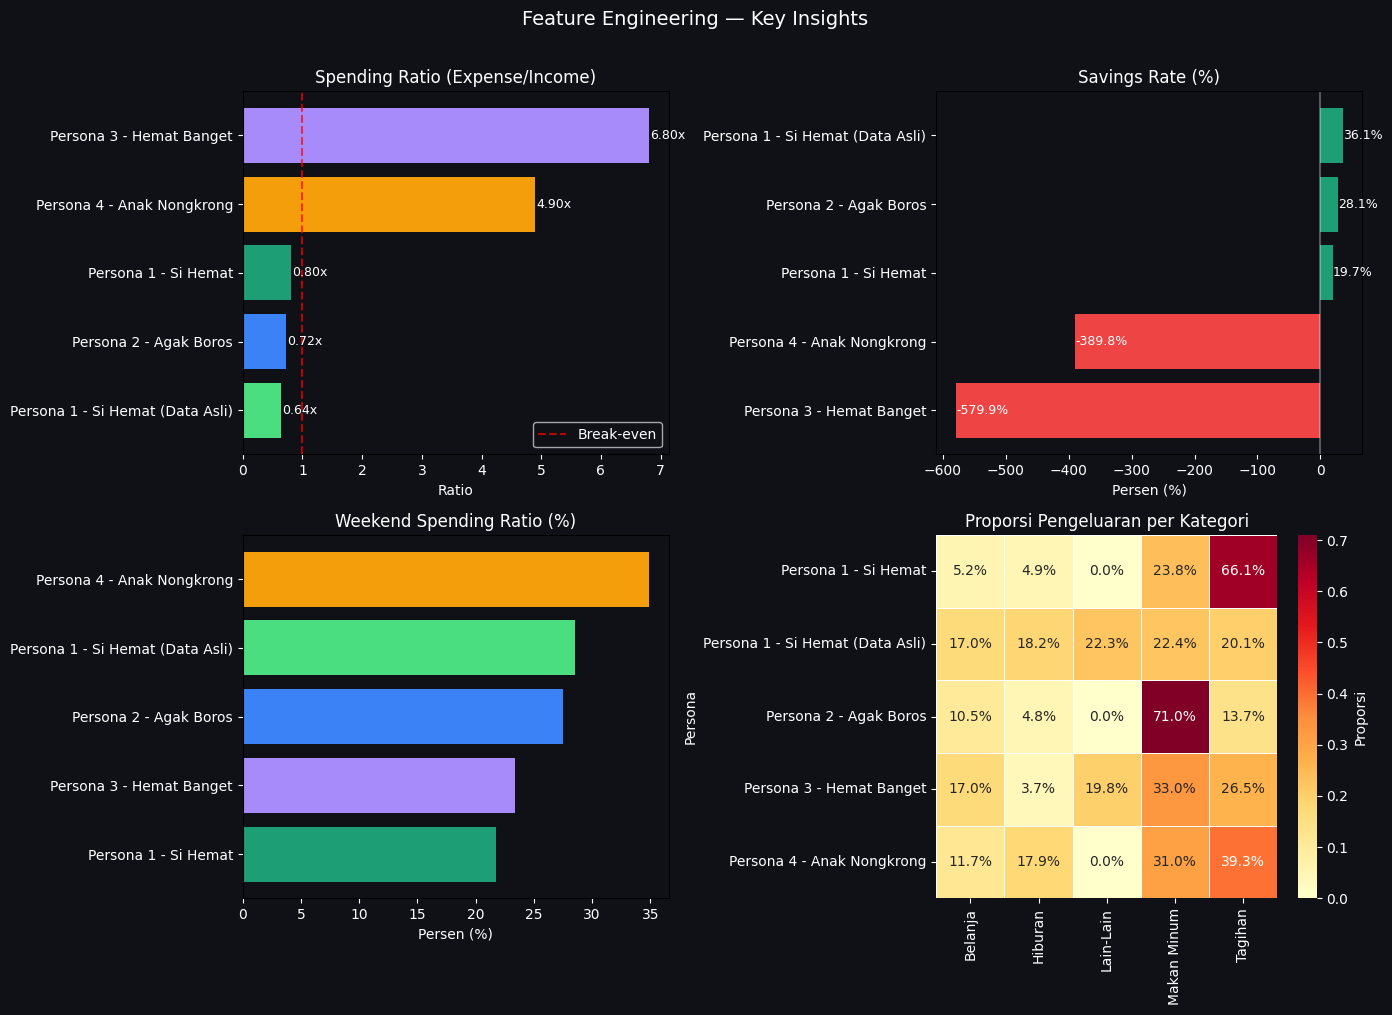

✅ Visualisasi disimpan!


In [37]:
COLORS = {
    'Persona 1 - Si Hemat': '#1D9E75',
    'Persona 1 - Si Hemat (Data Asli)': '#4ade80',
    'Persona 2 - Agak Boros': '#3b82f6',
    'Persona 3 - Hemat Banget': '#a78bfa',
    'Persona 4 - Anak Nongkrong': '#f59e0b',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering — Key Insights', color='white', fontsize=14, y=1.01)

personas = monthly['Persona'].unique()
palette  = [COLORS.get(p, '#64748b') for p in personas]

# 1. Spending Ratio
ax1 = axes[0, 0]
sr = monthly.groupby('Persona')['spending_ratio'].mean().sort_values()
bars = ax1.barh(sr.index, sr.values, color=[COLORS.get(p, '#64748b') for p in sr.index])
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Break-even')
ax1.set_title('Spending Ratio (Expense/Income)', color='white')
ax1.set_xlabel('Ratio', color='white')
ax1.legend()
for bar, val in zip(bars, sr.values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}x', va='center', color='white', fontsize=9)

# 2. Savings Rate
ax2 = axes[0, 1]
savr = monthly.groupby('Persona')['savings_rate'].mean().sort_values()
colors_sr = ['#ef4444' if v < 0 else '#1D9E75' for v in savr.values]
bars2 = ax2.barh(savr.index, savr.values, color=colors_sr)
ax2.axvline(x=0, color='white', linestyle='-', alpha=0.3)
ax2.set_title('Savings Rate (%)', color='white')
ax2.set_xlabel('Persen (%)', color='white')
for bar, val in zip(bars2, savr.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', color='white', fontsize=9)

# 3. Weekend Ratio
ax3 = axes[1, 0]
wr = monthly.groupby('Persona')['weekend_ratio'].mean().sort_values()
ax3.barh(wr.index, wr.values * 100, color=[COLORS.get(p, '#64748b') for p in wr.index])
ax3.set_title('Weekend Spending Ratio (%)', color='white')
ax3.set_xlabel('Persen (%)', color='white')

# 4. Category Ratio heatmap
ax4 = axes[1, 1]
ratio_cols_cat = [c for c in monthly.columns
                  if c.endswith('_ratio') and c not in ['spending_ratio','weekend_ratio']]
heatmap_data = monthly.groupby('Persona')[ratio_cols_cat].mean()
heatmap_data.columns = [c.replace('_ratio','').replace('_',' ').title()
                        for c in heatmap_data.columns]
sns.heatmap(heatmap_data, ax=ax4, cmap='YlOrRd', fmt='.1%', annot=True,
            cbar_kws={'label': 'Proporsi'}, linewidths=0.5)
ax4.set_title('Proporsi Pengeluaran per Kategori', color='white')
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../Dataset/Processed/feature_insights.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('✅ Visualisasi disimpan!')

## 6. Gabung Semua Fitur & Simpan

In [38]:
# === DATASET LEVEL BULANAN (untuk model & analisis) ===
print('=== df_monthly_features ===' )
print(f'Shape: {monthly.shape}')
print(f'Kolom: {monthly.columns.tolist()}')
print()
print(monthly.head(3).to_string())

monthly.to_csv('../Dataset/Processed/df_monthly_features.csv', index=False)
print('\n✅ df_monthly_features.csv tersimpan!')

=== df_monthly_features ===
Shape: (54, 25)
Kolom: ['Persona', 'YearMonth', 'total_expense', 'total_income', 'spending_ratio', 'savings_rate', 'net_balance', 'active_days', 'daily_avg_expense', 'dominant_category', 'belanja_amount', 'hiburan_amount', 'lain-lain_amount', 'makan_minum_amount', 'tagihan_amount', 'belanja_ratio', 'hiburan_ratio', 'lain-lain_ratio', 'makan_minum_ratio', 'tagihan_ratio', 'weekday_expense', 'weekend_expense', 'weekend_ratio', 'expense_volatility', 'mom_expense_change']

                Persona YearMonth  total_expense  total_income  spending_ratio  savings_rate  net_balance  active_days  daily_avg_expense dominant_category  belanja_amount  hiburan_amount  lain-lain_amount  makan_minum_amount  tagihan_amount  belanja_ratio  hiburan_ratio  lain-lain_ratio  makan_minum_ratio  tagihan_ratio  weekday_expense  weekend_expense  weekend_ratio  expense_volatility  mom_expense_change
0  Persona 1 - Si Hemat   2024-01      3736607.0     4498619.0        0.830612     16.

In [39]:
# === DATASET LEVEL TRANSAKSI (dengan cyclical encoding) ===
feature_cols = [
    'Date', 'Description', 'Amount', 'Transaction_Type',
    'Category', 'Account_Name', 'Persona',
    'Month', 'Month_Name', 'Day_of_Week',
    'month_sin', 'month_cos', 'day_sin', 'day_cos'
]

df_features = df[feature_cols].copy()
df_features = pd.merge(
    df_features,
    daily_total[['Persona','Date','daily_total','high_spend_flag']],
    on=['Persona','Date'], how='left'
)

print('=== df_features (transaction level) ===')
print(f'Shape: {df_features.shape}')
print(df_features.head(3).to_string())

df_features.to_csv('../Dataset/Processed/df_features.csv', index=False)
print('\n✅ df_features.csv tersimpan!')

=== df_features (transaction level) ===
Shape: (4981, 16)
        Date    Description    Amount Transaction_Type   Category Account_Name                           Persona  Month Month_Name Day_of_Week  month_sin  month_cos   day_sin  day_cos  daily_total  high_spend_flag
0 2025-07-01         Parkir  15907.28          EXPENSE    Tagihan        Gopay  Persona 1 - Si Hemat (Data Asli)      7       July     Tuesday       -0.5  -0.866025  0.781831  0.62349     60335.65              0.0
1 2025-07-01  Iuran Bulanan  12793.08          EXPENSE    Tagihan          BCA  Persona 1 - Si Hemat (Data Asli)      7       July     Tuesday       -0.5  -0.866025  0.781831  0.62349     60335.65              0.0
2 2025-07-01      Lain-lain    695.24          EXPENSE  Lain-lain        Gopay  Persona 1 - Si Hemat (Data Asli)      7       July     Tuesday       -0.5  -0.866025  0.781831  0.62349     60335.65              0.0

✅ df_features.csv tersimpan!


## 7. Ringkasan Insight dari Fitur Baru

In [40]:
print('=' * 60)
print('📊 RINGKASAN FEATURE ENGINEERING')
print('=' * 60)

summary = monthly.groupby('Persona').agg(
    Spending_Ratio   = ('spending_ratio',     'mean'),
    Savings_Rate_Pct = ('savings_rate',       'mean'),
    Daily_Avg_Exp    = ('daily_avg_expense',  'mean'),
    Weekend_Ratio    = ('weekend_ratio',       'mean'),
    Volatility       = ('expense_volatility', 'mean'),
).round(2)

summary['Daily_Avg_Exp'] = summary['Daily_Avg_Exp'].apply(
    lambda x: f'Rp {x:,.0f}'.replace(',','.'))
summary['Volatility'] = summary['Volatility'].apply(
    lambda x: f'Rp {x:,.0f}'.replace(',','.'))
summary['Savings_Rate_Pct'] = summary['Savings_Rate_Pct'].apply(
    lambda x: f'{x:.1f}%')
summary['Weekend_Ratio'] = summary['Weekend_Ratio'].apply(
    lambda x: f'{x:.1%}')

print(summary.to_string())
print()
print('Output files:')
print('  📁 Dataset/Processed/df_features.csv         (transaction level)')
print('  📁 Dataset/Processed/df_monthly_features.csv (monthly level)')
print('  📁 Dataset/Processed/feature_insights.png    (visualisasi)')

📊 RINGKASAN FEATURE ENGINEERING
                                  Spending_Ratio Savings_Rate_Pct Daily_Avg_Exp Weekend_Ratio  Volatility
Persona                                                                                                  
Persona 1 - Si Hemat                        0.80            19.7%     Rp 99.093         22.0%  Rp 162.332
Persona 1 - Si Hemat (Data Asli)            0.64            36.1%     Rp 51.389         29.0%   Rp 25.073
Persona 2 - Agak Boros                      0.72            28.1%    Rp 133.412         28.0%  Rp 134.576
Persona 3 - Hemat Banget                    6.80          -579.9%     Rp 39.485         23.0%   Rp 53.662
Persona 4 - Anak Nongkrong                  4.90          -389.8%    Rp 241.151         35.0%  Rp 343.235

Output files:
  📁 Dataset/Processed/df_features.csv         (transaction level)
  📁 Dataset/Processed/df_monthly_features.csv (monthly level)
  📁 Dataset/Processed/feature_insights.png    (visualisasi)
